# Positron Implantation and Annihilation Profiles with SciPAS

This notebook demonstrates how to compute positron **implantation profiles** and **equilibrium annihilation profiles** for a layered sample using SciPAS.

## Background

A mono-energetic positron beam implants positrons at a depth distribution determined by the beam energy and material stopping power. Two empirical parametrisations are supported:

- **Makhov profile** — widely used for metals and simple inorganic compounds;   parameterised by atomic number Z and density.
- **Ghosh profile** — extends Makhov with a more general functional form;   recommended for compounds and non-metallic materials (SiO₂, polymers, etc.).

After stopping, positrons diffuse and either annihilate in the bulk or reach a defect / surface. The **transport equation** (diffusion–annihilation PDE) gives the steady-state annihilation profile c(z), from which the annihilation fractions per layer are computed. These fractions are the direct input to VEDB diffusion-length fitting (see `vedb_diffusion_length_measurement.ipynb`).

## Sample: 200 nm SiO₂ on Si

A classic VEDB test structure. The oxide layer has a short positron diffusion length (Ps formation, interface defects); the Si substrate has a longer bulk value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipas.transport import (
    ghosh_material_parameters, makhov_material_parameters,
    ghosh_profile, makhov_profile,
    multilayer_implantation_profile, profile_solver,
)
from scipas.model import Material, Layer, Sample
from scipas.analysis import compute_annihilation_fractions

## 1. Sample definition

The sample consists of a 200 nm SiO₂ layer on a semi-infinite Si substrate. Diffusion lengths are set to typical literature values: L₀ = 3 nm in the oxide (Ps formation and interface defects suppress free-positron diffusion) and L₁ = 150 nm in crystalline Si.

> **Adapt** layer widths, diffusion lengths, and absorption length to your sample.

In [2]:
# ── Adapt to your sample ──────────────────────────────────────────────────────
oxide_width       = 200    # SiO₂ layer thickness [nm]
substrate_width   = 10_000 # Si substrate (effectively semi-infinite) [nm]
L0                = 3.0    # positron diffusion length in SiO₂ [nm]
L1                = 150.0  # positron diffusion length in Si [nm]
absorption_length = 1.0    # surface absorption length [nm]
D                 = 1.0    # normalised diffusion coefficient (only L = sqrt(D/λ) matters)
# ─────────────────────────────────────────────────────────────────────────────

oxide_layer     = Layer(width=oxide_width,
                        material=Material(diffusion=D, mobility=0,
                                          bulk_annihilation_rate=D / L0**2))
substrate_layer = Layer(width=substrate_width,
                        material=Material(diffusion=D, mobility=0,
                                          bulk_annihilation_rate=D / L1**2))
sample = Sample(layers=[oxide_layer, substrate_layer],
                absorption_length=absorption_length)

print(f'Sample: {oxide_width} nm SiO₂ (L₀ = {L0} nm)  /  Si substrate (L₁ = {L1} nm)')
print(f'Total depth: {sample.sample_length():.0f} nm')

Sample: 200 nm SiO₂ (L₀ = 3.0 nm)  /  Si substrate (L₁ = 150.0 nm)
Total depth: 10200 nm


## 2. Makhov vs Ghosh profiles

Both models describe how positrons stop in matter, but differ in their parametrisation:

- **Makhov**: uses tabulated Z, m, n, and A_half parameters; well-validated for   elemental metals. The density must be set by the user (the table stores   normalised shape parameters only).
- **Ghosh**: uses a richer parametrisation; includes compounds such as SiO₂   directly with their bulk densities.

For compound samples (oxides, semiconductors, polymers), **Ghosh is preferred**. For elemental metals, both give similar results and Makhov is often used.

> **Adapt** the row indices below if your material is different from SiO₂/Si. > Print `ghosh_material_parameters()` or `makhov_material_parameters()` to see > the full tables.

In [3]:
ghosh_params  = ghosh_material_parameters()
makhov_params = makhov_material_parameters()

# SiO₂: row 19 in both tables; Si: row 5
SiO2_ghosh = ghosh_params.iloc[19]
Si_ghosh   = ghosh_params.iloc[5]

SiO2_makhov = makhov_params.iloc[19].copy()
SiO2_makhov['density'] = 2.65    # g/cm³ — must be set manually for Makhov
Si_makhov   = makhov_params.iloc[5].copy()
Si_makhov['density']   = 2.329

print('SiO₂ Ghosh params:')
print(SiO2_ghosh[['density','Z','m','l']].to_string())
print()
print('SiO₂ Makhov params:')
print(SiO2_makhov[['density','Z','m','n']].to_string())

SiO₂ Ghosh params:
density    2.65
Z           0.0
m          4.47
l          0.61

SiO₂ Makhov params:
density     2.65
Z              0
m           2.19
n          1.774


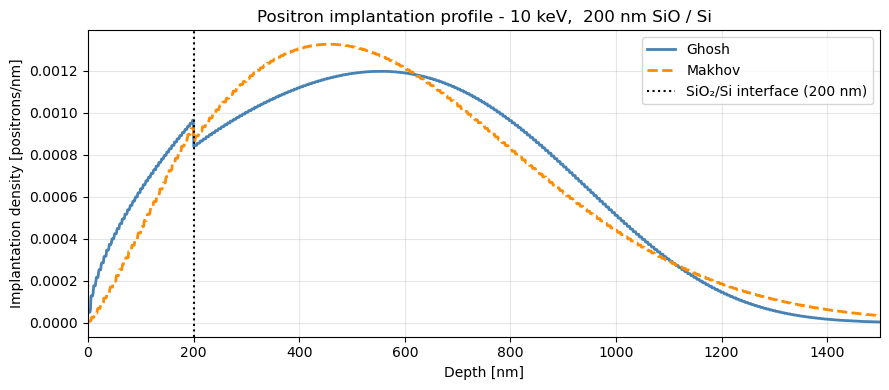

In [4]:
# ── Adapt the beam energy ─────────────────────────────────────────────────────
beam_energy = 10.0   # positron beam energy [keV]
# ─────────────────────────────────────────────────────────────────────────────

depth  = np.linspace(0, sample.sample_length(), 10_000)   # [nm]
widths    = [oxide_width, substrate_width]
densities = [SiO2_ghosh['density'], Si_ghosh['density']]

profile_ghosh  = multilayer_implantation_profile(
    positron_energy=beam_energy, depth_vector=depth,
    widths=widths, materials_parameters=[SiO2_ghosh, Si_ghosh],
    densities=densities, implantation_profile_function=ghosh_profile)

profile_makhov = multilayer_implantation_profile(
    positron_energy=beam_energy, depth_vector=depth,
    widths=widths,
    materials_parameters=[SiO2_makhov, Si_makhov],
    densities=[SiO2_makhov['density'], Si_makhov['density']],
    implantation_profile_function=makhov_profile)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(profile_ghosh.coords['x'].values,  profile_ghosh.values,  color='steelblue', lw=2, label='Ghosh')
ax.plot(profile_makhov.coords['x'].values, profile_makhov.values, color='darkorange', lw=2, ls='--', label='Makhov')
ax.axvline(oxide_width, color='black', ls=':', lw=1.5, label=f'SiO\u2082/Si interface ({oxide_width} nm)')
ax.set_xlabel('Depth [nm]')
ax.set_ylabel('Implantation density [positrons/nm]')
ax.set_title(f'Positron implantation profile - {beam_energy:.0f} keV,  {oxide_width} nm SiO / Si')
ax.set_xlim(0, 1500)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Profiles at multiple beam energies

The mean stopping depth increases with beam energy. Plotting profiles for several energies illustrates the VEDB principle: by varying the beam energy, positrons are implanted at different depths, sampling the S parameter as a function of depth.

/tmp/ipykernel_191457/871342311.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, depth[-1] * 0.35)


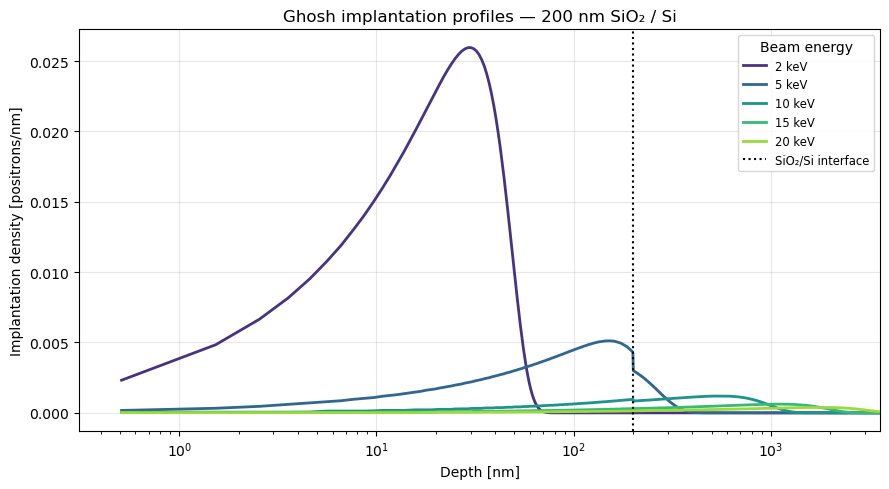

In [5]:
# ── Adapt energy range ────────────────────────────────────────────────────────
energies_keV = [2, 5, 10, 15, 20]   # beam energies to compare [keV]
# ─────────────────────────────────────────────────────────────────────────────

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(energies_keV)))

fig, ax = plt.subplots(figsize=(9, 5))
for e, color in zip(energies_keV, colors):
    prof = multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=widths, materials_parameters=[SiO2_ghosh, Si_ghosh],
        densities=densities, implantation_profile_function=ghosh_profile)
    ax.plot(prof.coords['x'].values, prof.values, color=color, lw=2, label=f'{e} keV')
ax.set_xscale('log')
ax.axvline(oxide_width, color='black', ls=':', lw=1.5, label='SiO\u2082/Si interface')
ax.set_xlabel('Depth [nm]')
ax.set_ylabel('Implantation density [positrons/nm]')
ax.set_title(f'Ghosh implantation profiles \u2014 {oxide_width} nm SiO\u2082 / Si')
ax.set_xlim(0, depth[-1] * 0.35)
ax.legend(title='Beam energy', fontsize='small')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Equilibrium annihilation profile

After implantation, positrons diffuse and annihilate. `profile_solver` solves the 1D steady-state transport equation:

$$\frac{d}{dz}\left[D(z)\,\frac{dc}{dz}\right] - \lambda(z)\,c(z) = -I(z)$$

with **radiative boundary conditions** at both surfaces. The result c(z) is the spatial distribution of annihilations, which differs from the implantation profile I(z) because positrons diffuse before annihilating.

The comparison of I(z) and c(z) makes the effect of diffusion visible: the annihilation profile is broadened and shifted relative to the stopping profile, especially when L₀ or L₁ is comparable to the layer width.

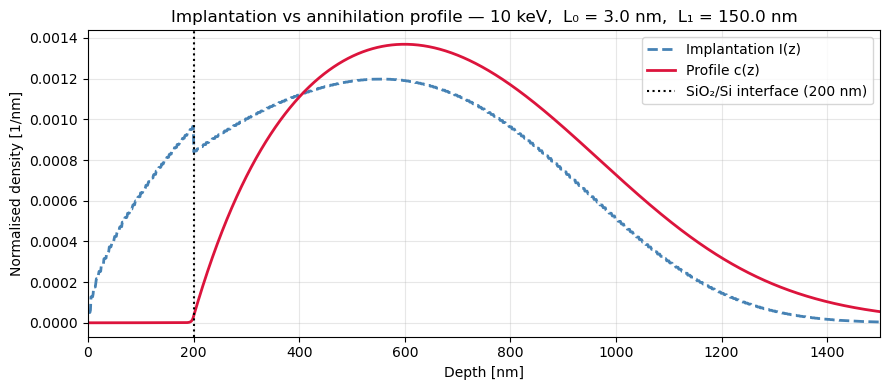

In [6]:
# Use the Ghosh profile at 10 keV for the transport calculation
implantation = multilayer_implantation_profile(
    positron_energy=10.0, depth_vector=depth,
    widths=widths, materials_parameters=[SiO2_ghosh, Si_ghosh],
    densities=densities, implantation_profile_function=ghosh_profile)

# Solve transport equation
annihilation = profile_solver(implantation, sample, mesh_size=10_000)

# Normalise both to integrate to 1 for direct shape comparison
I_norm = implantation / float(implantation.integrate('x'))
c_norm = annihilation / float(annihilation.integrate('x'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(I_norm.coords['x'].values, I_norm.values,
        color='steelblue', lw=2, ls='--', label='Implantation I(z)')
ax.plot(c_norm.coords['x'].values,  c_norm.values,
        color='crimson',   lw=2,       label='Profile c(z)')
ax.axvline(oxide_width, color='black', ls=':', lw=1.5,
           label=f'SiO\u2082/Si interface ({oxide_width} nm)')
ax.set_xlabel('Depth [nm]')
ax.set_ylabel('Normalised density [1/nm]')
ax.set_title(f'Implantation vs annihilation profile \u2014 10 keV,  L\u2080 = {L0} nm,  L\u2081 = {L1} nm')
ax.set_xlim(0, 1500)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Annihilation fractions per layer

`compute_annihilation_fractions` decomposes the total annihilation into contributions from:

- **Surface** (layer = −1): positrons reaching z = 0 and absorbed there
- **Layer 0** (SiO₂): positrons annihilating within the oxide layer
- **Layer 1** (Si): positrons annihilating in the Si substrate

These fractions are the direct inputs to `DiffusionLengthOptimization` in the VEDB fitting workflow. For a series of beam energies the fractions trace out how the annihilation shifts from surface → oxide → bulk as the beam energy increases.

Annihilation fractions at 10 keV:
  Surface        : 0.000  (0.0 %)
  SiO₂ layer     : 0.289  (28.9 %)
  Si substrate   : 0.711  (71.1 %)


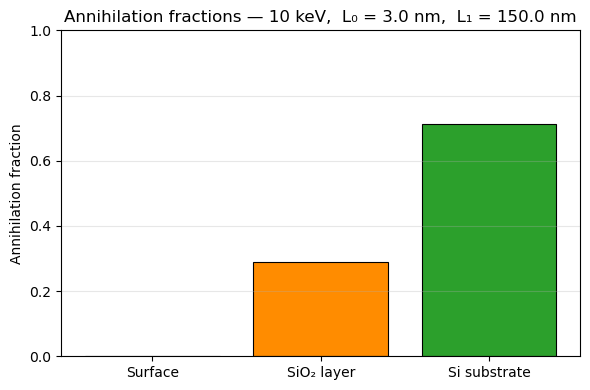

In [7]:
fracs = compute_annihilation_fractions(annihilation, sample)
labels = ['Surface', 'SiO₂ layer', 'Si substrate']

print(f'Annihilation fractions at {beam_energy:.0f} keV:')
for label, val in zip(labels, fracs.values):
    print(f'  {label:15s}: {val:.3f}  ({val*100:.1f} %)')

fig, ax = plt.subplots(figsize=(6, 4))
colors_bar = ['steelblue', 'darkorange', 'tab:green']
ax.bar(labels, fracs.values, color=colors_bar, edgecolor='black', lw=0.8)
ax.set_ylabel('Annihilation fraction')
ax.set_title(f'Annihilation fractions — {beam_energy:.0f} keV,  '
             f'L₀ = {L0} nm,  L₁ = {L1} nm')
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fractions vs beam energy

Computing the fractions at multiple energies shows how the S parameter is built up in a VEDB measurement. At low energies the oxide and surface dominate; at high energies the Si substrate takes over. The energy at which the oxide→substrate transition occurs encodes the diffusion length in the oxide layer.

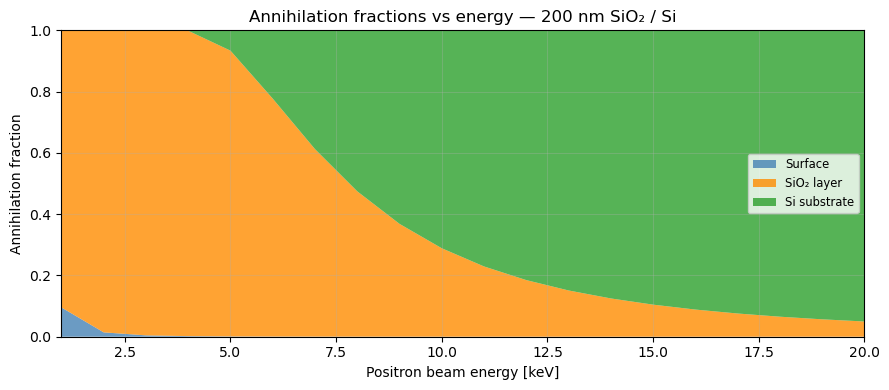

In [8]:
scan_energies = np.arange(1.0, 21.0, 1.0)   # [keV]
frac_surface = np.zeros(len(scan_energies))
frac_oxide   = np.zeros(len(scan_energies))
frac_si      = np.zeros(len(scan_energies))

for k, e in enumerate(scan_energies):
    prof = multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=widths, materials_parameters=[SiO2_ghosh, Si_ghosh],
        densities=densities, implantation_profile_function=ghosh_profile)
    ann  = profile_solver(prof, sample, mesh_size=10_000)
    f    = compute_annihilation_fractions(ann, sample).values
    frac_surface[k], frac_oxide[k], frac_si[k] = f

fig, ax = plt.subplots(figsize=(9, 4))
ax.stackplot(scan_energies, frac_surface, frac_oxide, frac_si,
             labels=['Surface', 'SiO₂ layer', 'Si substrate'],
             colors=['steelblue', 'darkorange', 'tab:green'], alpha=0.8)
ax.set_xlabel('Positron beam energy [keV]')
ax.set_ylabel('Annihilation fraction')
ax.set_title(f'Annihilation fractions vs energy — {oxide_width} nm SiO₂ / Si')
ax.set_xlim(scan_energies[0], scan_energies[-1])
ax.set_ylim(0, 1)
ax.legend(loc='center right', fontsize='small')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()